Supongamos que observamos un sistema dinámico sobre una región espacial representada por una cuadrícula $MxN$ que consta de $M$ filas y $N$ columnas. Dentro de cada celda de la cuadrícula, hay $P$ mediciones que varían con el tiempo. Por lo tanto, la observación en cualquier momento puede representarse mediante un tensor $$X \in R^{PxMxN} $$

donde $R$ denota el dominio de las características observadas. Si registramos las observaciones periódicamente, obtendremos una secuencia de tensores $\hat{X}_{1},\hat{X}_{2},\cdots,\hat{X}_{n}$ *el problema de predicción de secuencias espacio-temporales es predecir la secuencia de longitud $K$ más probable en el futuro dadas las $J$ observaciones anteriores que incluyen la actual*

$$\hat{X}_{t+1},\cdots,\hat{X}_{t+K} = arg max_{\hat{X}_{t+1},\cdots,\hat{X}_{t
+K}} p(\hat{X}_{t+1},\cdots,\hat{X}_{t+K} | \hat{X}_{t+1},\cdots,\hat{X}_{t-J+1},\hat{X}_{t-J+2},\cdots,\hat{X}_{t})$$


RNN: https://www.aprendemachinelearning.com/como-funcionan-las-convolutional-neural-networks-vision-por-ordenador/

In [1]:
!pip install rasterio
import numpy as np
import pandas as pd
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import rasterio
import glob
from scipy.ndimage import zoom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 39.2 MB/s eta 0:00:00


# Referencia

Qué es un raster? https://desktop.arcgis.com/es/arcmap/latest/manage-data/raster-and-images/what-is-raster-data.htm

https://www.kaggle.com/code/kcostya/convlstm-convolutional-lstm-network-tutorial

An introduction to convlstm
https://medium.com/neuronio/an-introduction-to-convlstm-55c9025563a7


https://www.youtube.com/watch?v=bKkjQx_PS_M&list=PL9E7H1rzXKFKRQA2TiNRJG3bezPDxG6c3&index=1


Video Frame Prediction using ConvLSTM Network in PyTorch:
https://sladewinter.medium.com/video-frame-prediction-using-convlstm-network-in-pytorch-b5210a6ce582

Aquí se importan las bibliotecas necesarias para construir y entrenar el modelo. Las bibliotecas tensorflow y keras proporcionan herramientas para construir redes neuronales. numpy se usa para operaciones matemáticas y manipulación de matrices, mientras que pylab (de matplotlib) es útil para visualizar resultados.

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Conv3D
from tensorflow.keras.layers import ConvLSTM2D
from tensorflow.keras.layers import BatchNormalization
import pylab as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Para comprobar el tipo de GPU asignada a nuestro portátil, utilizamos el siguiente comando.
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [5]:
%cd '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv'
%ls

/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv
 convLSTM_3.ipynb
'Copia de Crime_ConvLSTM_Network_AB_V1.ipynb'
'Copia de Crime_ConvLSTM_Network_AB_V2.ipynb'
 input/
 input2/
 output/
'revision v1 artículo Julio Crimen.docx'
'revisión v2 artículo crimen.docx'
 Untitled


In [6]:
# Ruta donde están almacenados los mapas de calor en formato raster
ruta_rasters =  '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/*.tif'
#ruta_rasters = '/content/drive/MyDrive/Taller de Complejidad/model_red_ConvLSTM/heatmaps/fiscalia/*.tif'
#ruta_rasters = '/content/drive/MyDrive/Taller de Complejidad/model_red_ConvLSTM/heatmaps/notas/*.tif'
ruta_salida = '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output/'

In [7]:
rasters = glob.glob(ruta_rasters)
print(f"Tenemos un total de '{len(rasters)}' mapas de calor")
#rasterio.open?

Tenemos un total de '72' mapas de calor


In [8]:
12*6

72

In [9]:
'''
Cargar las imágenes raster:
Se utiliza la biblioteca rasterio para leer cada archivo .tif desde una ruta definida (ruta_rasters).
La función glob.glob() obtiene todos los archivos que coinciden con el patrón especificado. '''

# 1. Cargar y redimensionar las imágenes raster
rasters = glob.glob(ruta_rasters)


#target_shape es una tupla que define el tamaño objetivo al que se quiere redimensionar la imagen, en este caso (80, 80).
target_shape = (90, 124)  # Tamaño fijo
row, col = target_shape


#Inicialización de la lista sequences
sequences = []

# rasterio.open(raster) abre el archivo raster en modo de lectura. rasterio es una librería de Python para leer y escribir datos geoespaciales en formatos de archivos raster.
# src.read(1) lee la primera banda de la imagen raster. Un archivo raster puede tener varias bandas (como las imágenes multiespectrales), y 1 indica que se lee solo la primera banda.
for raster in rasters:
    with rasterio.open(raster) as src:
        image = src.read(1)

        #zoom_factors calcula los factores de escala necesarios para redimensionar la imagen a target_shape.
        zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
        '''Por ejemplo, si la imagen original tiene un tamaño de (160, 160) y target_shape es (800, 80), entonces zoom_factors será (0.5, 0.5).'''
        resized_image = zoom(image, zoom_factors, order=1)
        #zoom(image, zoom_factors, order=1) redimensiona la imagen usando la función zoom de scipy.ndimage
        #order=1 indica que se utiliza la interpolación bilineal para realizar el redimensionamiento.
        sequences.append(resized_image)#La imagen redimensionada resized_image se agrega a la lista sequences, que contendrá todas las imágenes procesadas

''' Convierte la lista de imágenes redimensionadas en un array de numpy '''
sequences = np.array(sequences)
#Esta línea normaliza los valores de sequences dividiendo cada valor por el máximo valor del array. Esta normalización ajusta todos los valores a un rango de [0, 1], lo cual es beneficioso para muchos algoritmos de machine learning, especialmente redes neuronales, ya que mejora la estabilidad del entrenamiento y la convergencia.
sequences = sequences / sequences.max()

In [10]:

#sequences
sequences[1].shape

(90, 124)

In [11]:
#Acomodamos los 2 meses que estabam mal ordenados (101 y 102)
print(len(rasters))
#elemento_movido = rasters.pop(102)
#rasters.insert(73, elemento_movido)

72


In [ ]:
rasters[1:10]
#print(f"ultimos mes: '{rasters[71]}")

['/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_2.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_3.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_4.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_5.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_6.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_7.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_8.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_9.tif',
 '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/kde_200_900_1024_2018_10.tif']

In [ ]:
print(f'Existen {len(sequences)} mapas de calor')
print(sequences[1])

Existen 72 mapas de calor
[[0.00010183 0.00016676 0.00026999 ... 0.00020802 0.0002173  0.00022749]
 [0.00010793 0.00017603 0.00028375 ... 0.00030734 0.00032146 0.00033692]
 [0.00011439 0.00018587 0.00029838 ... 0.00044978 0.00047104 0.00049422]
 ...
 [0.02189999 0.02008799 0.01844879 ... 0.00051004 0.00039399 0.00030038]
 [0.02021152 0.01847805 0.01690762 ... 0.00039663 0.00030595 0.00023298]
 [0.01856135 0.01691702 0.01542523 ... 0.00030574 0.00023547 0.00017908]]


# Creamos la secuencia de imágenes raster


1. La **funcion** generate_noisy_shifted_sequences()

- Esta función toma sequences y genera dos matrices 5D: noisy_movies y shifted_movies.
- $\text{noisy_movies}[i]$ contiene una serie de n_frames frames(*lista de mapas de calor*) consecutivos, mientras que $\text{shifted_movies}[i]$ contiene los mismos frames(*lista mapas de calor*) pero desplazados una posición adelante.
- De este modo, $\text{shifted_movies}[i, t]$ representa el siguiente frame que la red ConvLSTM debe aprender a predecir usando $\text{noisy_movies}[i, t-1]$ como entrada.


2. noisy_movies contiene una secuencia de imágenes raster, y shifted_movies será la misma secuencia pero desplazada en el tiempo, de modo que $\text{noisy_movies}[0]$ corresponda a $\text{shifted_movies}[1]$. Esto se ajusta a una arquitectura de red LSTM que intenta predecir el siguiente frame en función de los anteriores.

3. Tamaño de las secuencias: La cantidad de secuencias disponibles es $\text{n_samples = sequences.shape[0] - n_frame}$, ya que cada secuencia usa n_frames consecutivos y hay un desplazamiento de 1 frame en shifted_movies.

4. Forma de las matrices: noisy_movies y shifted_movies tendrán la forma (n_samples, n_frames, 80, 80, 1), lo cual es adecuado para ingresar a una red ConvLSTM.



In [12]:
# 2. Generar secuencias para la ConvLSTM
# La función genera pares (entrada, objetivo) donde cada entrada es un frame
# y cada objetivo es el siguiente frame en la secuencia temporal.
def generate_noisy_shifted_sequences(sequences, n_frames=12):
    n_samples = sequences.shape[0] - n_frames  # Número de secuencias posibles
    print(f'Número de secuencias {n_samples}. Tamaño frame: {n_frames} (listas de mapas de calor)')
    #row, col = target_shape

    noisy_movies = np.zeros((n_samples, n_frames, row, col, 1), dtype=np.float64)
    shifted_movies = np.zeros((n_samples, n_frames, row, col, 1), dtype=np.float64)

    for i in range(n_samples):
        # Cada secuencia en noisy_movies es una serie de `n_frames` consecutivos de `sequences`
        noisy_movies[i, :, :, :, 0] = sequences[i:i + n_frames]

        # Cada secuencia en shifted_movies es el mismo conjunto, pero desplazado una posición en el tiempo
        shifted_movies[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]

    return noisy_movies, shifted_movies

In [13]:
len(sequences[0:0 + 12])

12

In [14]:
# Generar secuencias usando la función adaptada
noisy_movies, shifted_movies = generate_noisy_shifted_sequences(sequences)

print("Forma de noisy_movies:", noisy_movies.shape)
print("Forma de shifted_movies:", shifted_movies.shape)


Número de secuencias 60. Tamaño frame: 12 (listas de mapas de calor)
Forma de noisy_movies: (60, 12, 90, 124, 1)
Forma de shifted_movies: (60, 12, 90, 124, 1)


# noisy_movies y shifted_movies

In [15]:
noisy_movies.shape, shifted_movies.shape

((60, 12, 90, 124, 1), (60, 12, 90, 124, 1))

# Creación del modelo

Se inicializa un modelo secuencial de **Keras**, que permite apilar capas en secuencia.

Creamos una capa que toma como entrada películas de forma (n_fotogramas, ancho, alto, canales) y devuelve una película de forma idéntica.

- Se añaden varias capas ConvLSTM2D con la misma configuración y una capa de normalización tras cada una. Esto permite que el modelo aprenda patrones complejos y profundos en secuencias temporales.

In [17]:
# ========================================
# 1. Importaciones
# ========================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv3D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# ====== 1. Normalización de los datos ======
scaler = MinMaxScaler()
all_data = np.concatenate([noisy_movies.reshape(-1, 1), shifted_movies.reshape(-1, 1)])
scaler.fit(all_data)

X = scaler.transform(noisy_movies.reshape(-1,1)).reshape(noisy_movies.shape)
Y = scaler.transform(shifted_movies.reshape(-1,1)).reshape(shifted_movies.shape)

# ====== 2. Construcción del modelo ======
print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ========================================
# 3. Escalado global
# ========================================
scaler = MinMaxScaler()

X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)

scaler.fit(np.vstack([X_flat, Y_flat]))  # Ajustamos en TODO el dataset

X_scaled = scaler.transform(X_flat).reshape(X.shape)
Y_scaled = scaler.transform(Y_flat).reshape(Y.shape)

# ========================================
# 4. Split temporal simple
# ========================================
n_samples = X_scaled.shape[0]
train_end = int(0.7 * n_samples)
val_end = int(0.9 * n_samples)

X_train, Y_train = X_scaled[:train_end], Y_scaled[:train_end]
X_val, Y_val = X_scaled[train_end:val_end], Y_scaled[train_end:val_end]
X_test, Y_test = X_scaled[val_end:], Y_scaled[val_end:]

print("Train:", X_train.shape, Y_train.shape)
print("Val:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

# ========================================
# 5. Definir modelo ConvLSTM
# ========================================
seq = Sequential()
for _ in range(4):
    seq.add(ConvLSTM2D(filters=36, kernel_size=(3,3),
                       padding='same', return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.2,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))
    #seq.add(BatchNormalization())

seq.add(Conv3D(filters=1, kernel_size=(3,3,3),
               activation='sigmoid', padding='same',
               kernel_regularizer=l2(1e-4)))

seq.compile(loss='mean_absolute_error', optimizer='adadelta')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# ========================================
# 6. Entrenamiento ConvLSTM
# ========================================
history = seq.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=2,
    callbacks=callbacks
)

# ========================================
# 7. Predicciones ConvLSTM
# ========================================
Y_pred = seq.predict(X_test)

# Inversa del escalado
Y_pred_inv = scaler.inverse_transform(Y_pred.reshape(-1, 1)).reshape(Y_pred.shape)
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1)).reshape(Y_test.shape)

# Usamos SOLO primer paso de salida
y_true = Y_test_inv[:, 0, :, :, 0]
y_pred = Y_pred_inv[:, 0, :, :, 0]

# ========================================
# 8. Métricas auxiliares
# ========================================
def top_k_mask(arr, k=0.1):
    thresh = np.quantile(arr, 1 - k)
    return arr >= thresh

def pai(y_true, y_pred, k=0.1):
    mask_pred = top_k_mask(y_pred, k)
    A = mask_pred.sum()
    N = y_true.sum()
    nA = y_true[mask_pred].sum()
    return (nA / N) / (A / y_true.size) if N > 0 and A > 0 else 0

def spatial_iou(y_true, y_pred, k=0.1):
    mask_true = top_k_mask(y_true, k)
    mask_pred = top_k_mask(y_pred, k)
    inter = np.logical_and(mask_true, mask_pred).sum()
    union = np.logical_or(mask_true, mask_pred).sum()
    return inter / union if union > 0 else 0

def spatial_f1(y_true, y_pred, k=0.1):
    mask_true = top_k_mask(y_true, k).astype(int).flatten()
    mask_pred = top_k_mask(y_pred, k).astype(int).flatten()
    return f1_score(mask_true, mask_pred)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    return {
        "MAE": mae,
        "RMSE": rmse,
        "PAI": pai(y_true, y_pred),
        "IoU": spatial_iou(y_true, y_pred),
        "F1": spatial_f1(y_true, y_pred)
    }

# ========================================
# 9. Línea de Base Histórica
# ========================================
# Se asume que X e Y son mensuales. Usamos promedio de mismos meses previos.
def historical_baseline(sequences, test_index, period=12):
    if test_index < period:
        return sequences[test_index-1]  # fallback
    past = sequences[test_index-period:test_index:period]
    return np.mean(past, axis=0)

y_pred_hist = np.zeros_like(y_true)
for i in range(y_true.shape[0]):
    y_pred_hist[i] = historical_baseline(y_true, i)

# ========================================
# 10. Línea de Base ML (Random Forest)
# ========================================
H, W = y_true.shape[1], y_true.shape[2]
X_rf, Y_rf = [], []
lags = 3  # usar 3 meses previos

flat_seq = y_true.reshape(y_true.shape[0], -1)  # (T, H*W)

for t in range(lags, flat_seq.shape[0]):
    X_rf.append(flat_seq[t-lags:t].flatten())
    Y_rf.append(flat_seq[t])

X_rf, Y_rf = np.array(X_rf), np.array(Y_rf)

split = int(0.7 * X_rf.shape[0])
X_rf_train, X_rf_test = X_rf[:split], X_rf[split:]
Y_rf_train, Y_rf_test = Y_rf[:split], Y_rf[split:]

rf = RandomForestRegressor(n_estimators=50, n_jobs=-1)
rf.fit(X_rf_train, Y_rf_train)
Y_rf_pred = rf.predict(X_rf_test).reshape(-1, H, W)

# ========================================
# 11. Comparación de modelos
# ========================================
metrics_convlstm = compute_metrics(y_true, y_pred)
metrics_hist = compute_metrics(y_true, y_pred_hist)
metrics_rf = compute_metrics(Y_rf_test.reshape(-1, H, W), Y_rf_pred)

results = pd.DataFrame([metrics_convlstm, metrics_hist, metrics_rf],
                       index=["ConvLSTM", "Histórico", "RandomForest"])

print("\n=== Resultados comparativos ===")
print(results)

# ========================================
# 12. Gráficos comparativos
# ========================================
results.plot(kind="bar", figsize=(10,6))
plt.title("Comparación de modelos (MAE, RMSE, PAI, IoU, F1)")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()

X shape: (60, 12, 90, 124, 1)
Y shape: (60, 12, 90, 124, 1)
Train: (42, 12, 90, 124, 1) (42, 12, 90, 124, 1)
Val: (12, 12, 90, 124, 1) (12, 12, 90, 124, 1)
Test: (6, 12, 90, 124, 1) (6, 12, 90, 124, 1)
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 311s 14s/step - loss: 0.4860 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 319s 15s/step - loss: 0.4867 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 334s 16s/step - loss: 0.4905 - val_loss: 0.4294 - learning_rate: 0.0010
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 328s 16s/step - loss: 0.4847 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 323s 15s/step - loss: 0.4878 - val_loss: 0.4292 - learning_rate: 0.0010
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 331s 16s/step - loss: 0.4925 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 329s 16s/step - loss: 0.4913 - val_loss: 0.4290 - learning_rate: 0.0010
Epoch 8/20
21/21 ━━━━━━━━━━━

KeyboardInterrupt: 

# Parámetros C5

In [ ]:
batch_size = 11; #El tamaño del lote que se usa para actualizar los pesos del modelo después de cada pasada. Es decir, cuántas muestras se procesan antes de realizar un ajuste a los pesos del modelo.
epochs = 50; # El número de veces que el modelo verá todo el conjunto de entrenamiento. Una época implica que el modelo ha pasado por todas las muestras de entrenamiento una vez.
validation_split = 0.1;   # Es el porcentaje de los datos de entrenamiento que se usará como datos de validación para evaluar el rendimiento del modelo durante el entrenamiento.

# <font color="red"> Entrenando la red Convolutional LSTM Network</font>

El modelo se entrena con los primeros 72 que representan el 80% de los 91 mapa de calor (datos) de la lista (noisy_movies[:72]) y se valida con el 5% de los datos de entrenamiento, en lotes de tamaño 12 y por 5 épocas.


In [ ]:
# ====== 5. Entrenamiento ======
history = seq.fit(
    X, Y,
    batch_size= batch_size,
    epochs=epochs,
    validation_split= validation_split,
    shuffle=True,
    verbose=2,
    callbacks=callbacks
)

Epoch 1/50
5/5 - 76s - 15s/step - loss: 0.1512 - val_loss: 0.1547 - learning_rate: 1.0000e-03
Epoch 2/50
5/5 - 11s - 2s/step - loss: 0.1230 - val_loss: 0.1240 - learning_rate: 1.0000e-03
Epoch 3/50


Visualización de la estructura:

- Entrada: La red toma como entrada una secuencia de imágenes en escala de grises, cada una con dimensiones 80x80 píxeles.
- Capas ConvLSTM2D: Hay cuatro capas ConvLSTM2D apiladas una sobre otra. Cada capa tiene 40 filtros con un tamaño de núcleo de 3x3. Estas capas se encargan de extraer las características espaciotemporales de la secuencia de entrada. Tenga en cuenta que return_sequences=True permite apilar las capas ConvLSTM2D y pasar los datos de la secuencia a la siguiente capa.
- Normalización por lotes: Una capa de Normalización por Lotes sigue a cada capa ConvLSTM2D para ayudar a la estabilidad del entrenamiento. Capa Conv3D: La capa final es una capa Conv3D con 1 filtro y un tamaño de núcleo de 3x3x3. Esta capa procesa la salida de las capas ConvLSTM2D y realiza la predicción final. Utiliza una función de activación sigmoidea para la clasificación binaria.
- Salida: La red produce una secuencia de predicciones, cada una con dimensiones 80x80 píxeles. Los valores de la salida están entre 0 y 1 debido a la función de activación sigmoidea.

In [ ]:
seq.summary() # muestra la estructura y parámetros de las capas en el modelo, lo cual ayuda a visualizar la arquitectura.
#seq.save('/content/drive/MyDrive/Taller de Complejidad/model_red_ConvLSTM/my_model_fiscalia.h5')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_14 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        48,096 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_15 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_16 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_17 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 12, 90, 124, 1) │           973 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,313 (3.77 MB)

 Trainable params: 329,437 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 658,876 (2.51 MB)

# Guarda el modelo

In [ ]:
#from tensorflow.keras.utils import plot_model
#plot_model(seq, to_file='/content/drive/MyDrive/Taller de Complejidad/model_red_ConvLSTM/model_imagenes.png', show_shapes=True)

# Puedo proporcionarte una representación textual de la estructura de la red, que luego puedes utilizar para visualizarla con herramientas externas o incluso dibujarla tú mismo.

## <font color="#799b48"> Graficamos la evolución de la pérdida por época </font>

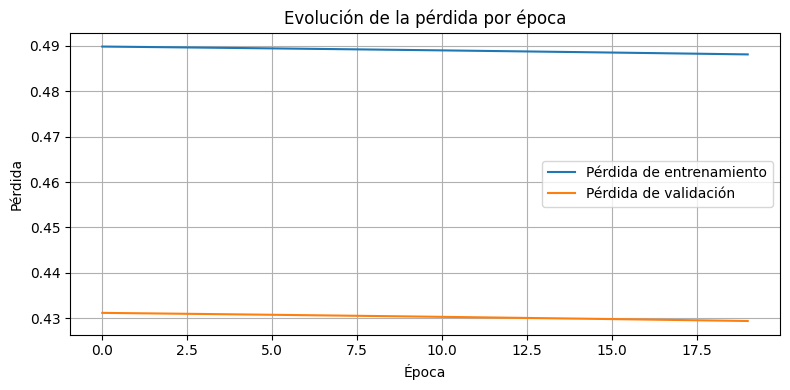

In [ ]:
# Graficar evolución de la pérdida
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Evolución de la pérdida por época')
#plt.savefig(f'{ruta_salida}evolucion_loss_predicciones_batch_size_{batch_size}_epochs_{epochs}_validation_split_{validation_split}_%i_animate_num_capas_{num_capas}_sin_normalizar.png')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## <font color="#00FFFF">Probando la red entrenada</font>

- which = 33: Seleccionamos la secuencia número 33 para realizar las predicciones.
- $\text{track = noisy_movies[which][:7, ::, ::, ::] }$
- Extraemos los primeros 7 mapas de calor de la secuencia seleccionada (son las observaciones iniciales que usamos como base para predecir los siguientes meses).

La dimensión del tensor resultante es (7, 90, 124, 1):
7 fotogramas.

Resolución espacial de 80x80 píxeles.
1 canal (dado que son mapas de calor).

In [ ]:
which = 22
track = noisy_movies[which][:7, ::, ::, ::]
track.shape

(7, 90, 124, 1)

In [ ]:
noisy_movies[which].shape #la secuencia 33 tiene los 12 meses

(12, 90, 124, 1)

Verifiquemos las dimensiones de la siguiente matriz para comprender mejor lo que sucede aquí. La pista tiene la forma de 7 cuadros de 90*124 con un canal. np.newaxis agrega un eje adicional para que el modelo de secuencia pueda aceptar la matriz.

In [ ]:
track.shape, track[np.newaxis, ::, ::, ::, ::].shape  #alimenta a seq para predecir

((7, 90, 124, 1), (1, 7, 90, 124, 1))

Bucle for j in range(12):

Predice 12 fotogramas adicionales (es decir, 1 año).
seq.predict():

Se utiliza la red entrenada para predecir el siguiente fotograma basado en los últimos 7 fotogramas almacenados en track.

Entrada:
track[np.newaxis, ::, ::, ::, ::]: Añadimos una dimensión adicional para que sea compatible con el formato esperado (lotes).

Salida:
Tensor new_pos con forma (1, 7, 80, 80, 1).
new = new_pos[::, -1, ::, ::, ::]:

Seleccionamos únicamente el último fotograma predicho (80, 80, 1).
track = np.concatenate((track, new), axis=0):

Concatenamos el fotograma predicho al tensor track, expandiendo la primera dimensión (ahora contiene tanto las observaciones iniciales como las predicciones).

In [ ]:
for j in range(12): #16 meses predichos
   # seq Guarda la red entrenada
    new_pos = seq.predict(track[np.newaxis, ::, ::, ::, ::]) # (1, 7, 80, 80, 1)
    new = new_pos[::, -1, ::, ::, ::] # (1, 80, 80, 1)
    #en track se guardan las prediccioenes
    track = np.concatenate((track, new), axis=0) # adds +1 to the first dimension in each loop cycle
    #contiene una pelicula

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
#len(track[1])
#print(f'{ruta_salida}%i_animate_.png')

Visualización inicial (ax = fig.add_subplot(121)):

Muestra los mapas de calor generados (predicciones y observaciones iniciales).
Usa track[i] para cada iteración del bucle.
Visualización del patrón verdadero (ax = fig.add_subplot(122)):

Muestra los valores reales correspondientes a las predicciones.
Usa shifted_movies[which][i - 1] para las observaciones reales, excepto para los primeros dos fotogramas (debido al índice).
plt.savefig():

Guarda cada par de gráficos en la ruta ruta_salida.

*Compare the predictions to the ground truth*


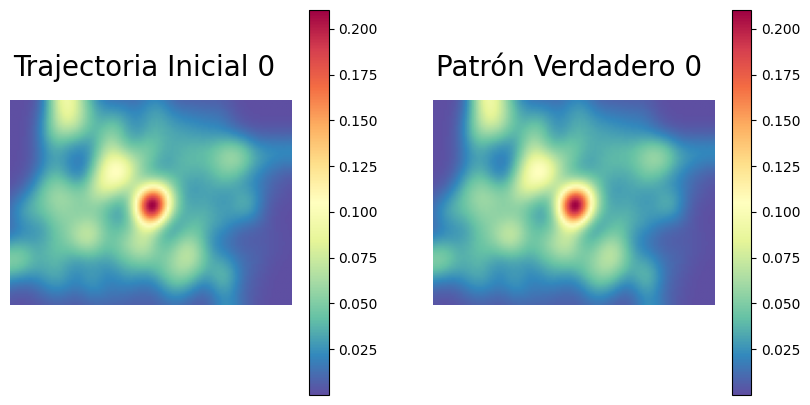

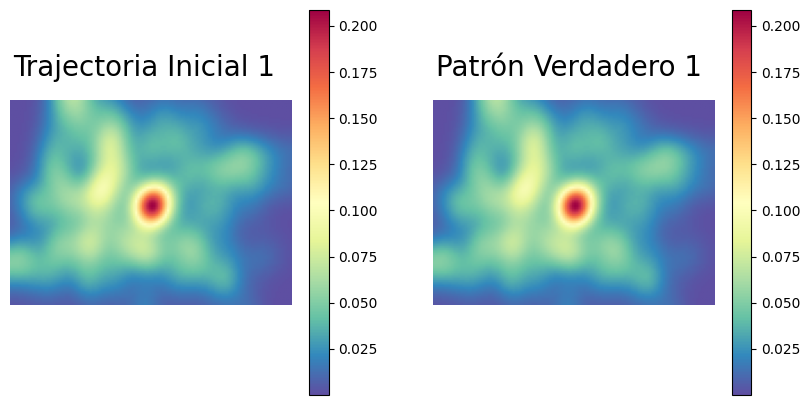

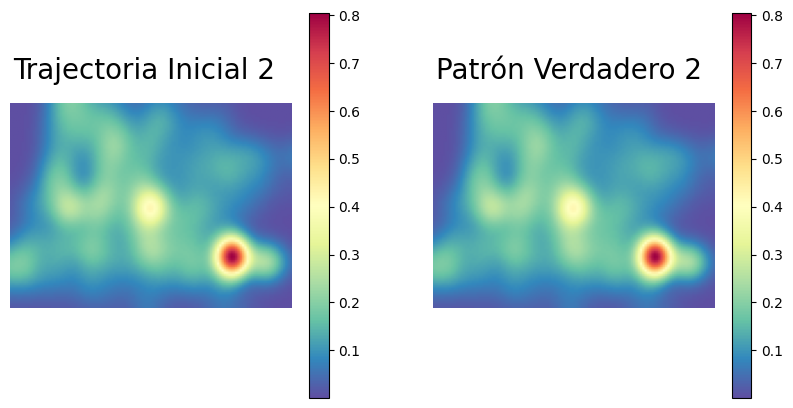

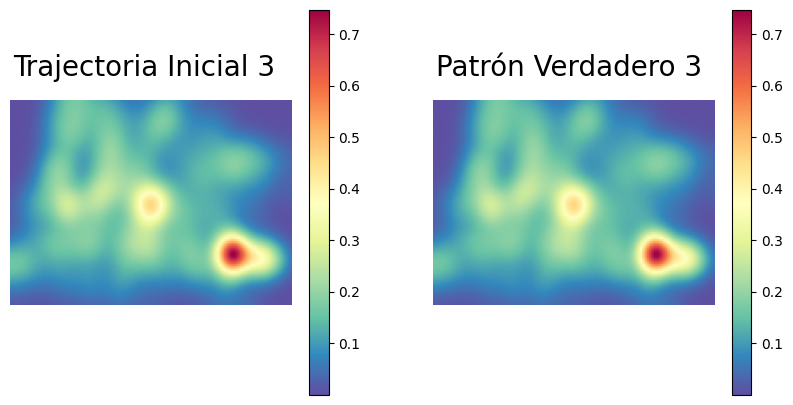

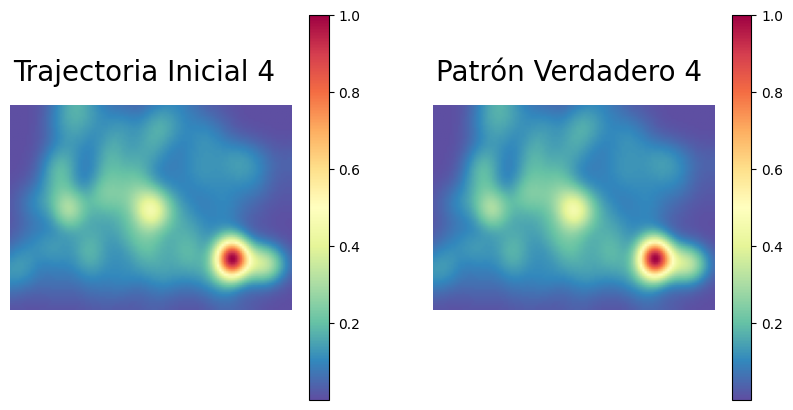

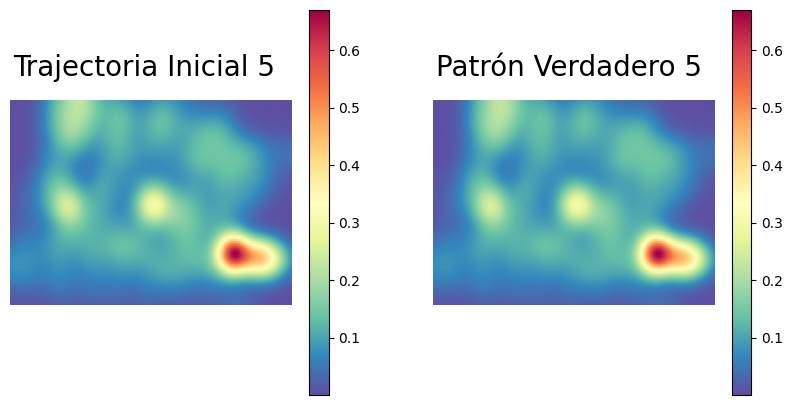

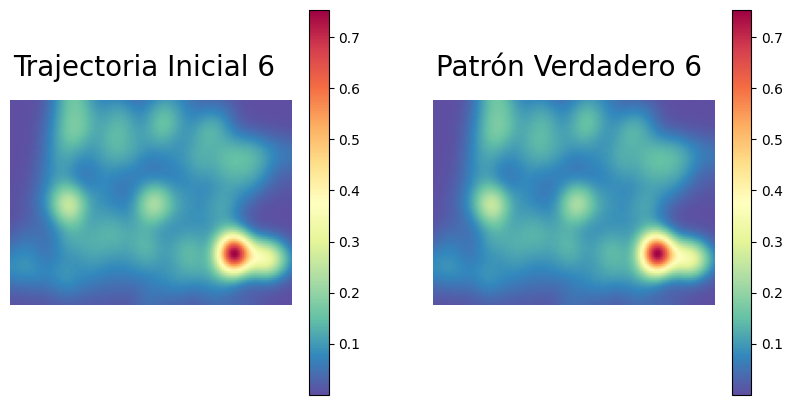

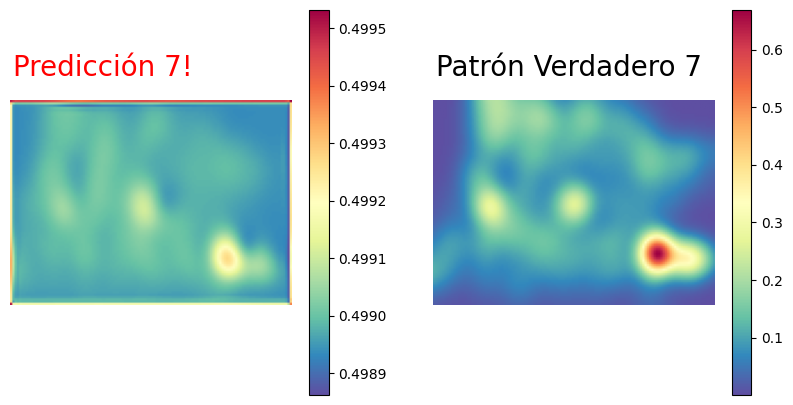

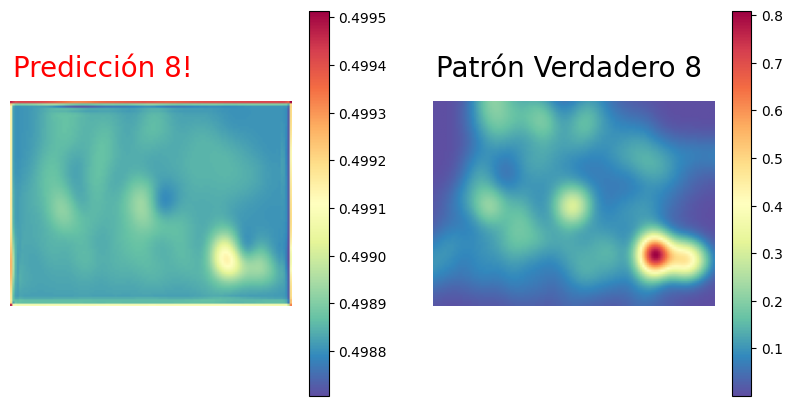

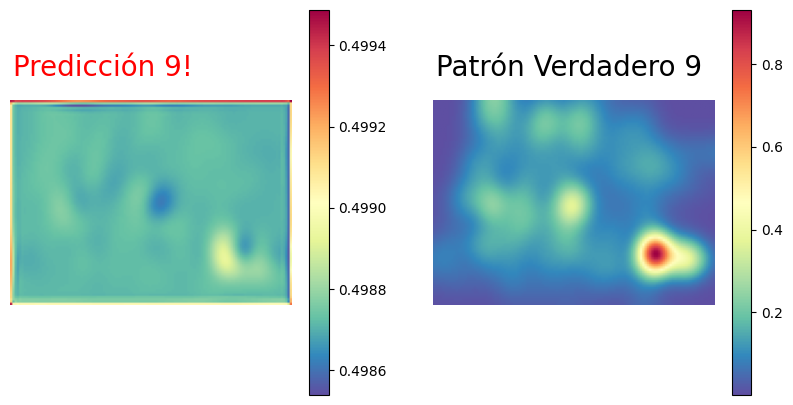

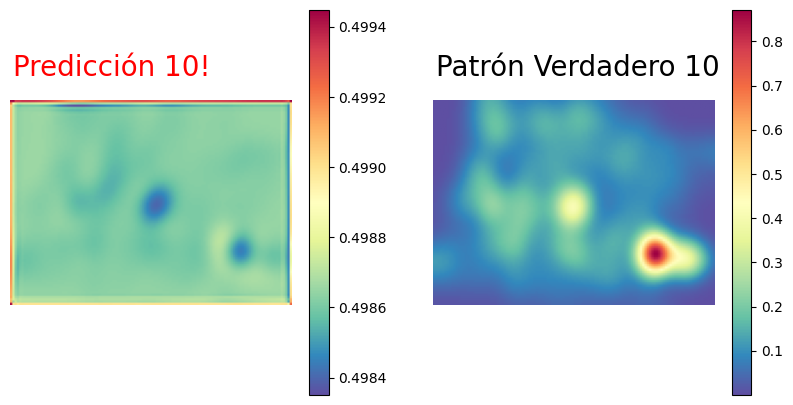

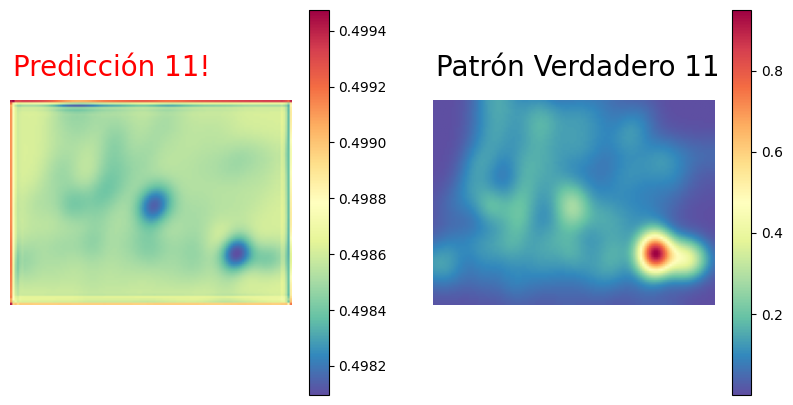

In [ ]:
#range debe ser menor a sample

for i in range(12): #range debe ser menor a sample
    fig = plt.figure(figsize=(10, 5))

    ax = fig.add_subplot(121)

    if i >= 7:
        ax.text(1, 3, f'Predicción {i}!\n', fontsize=20, color='r')
    else:
        ax.text(1, 3, f'Trajectoria Inicial {i}\n', fontsize=20)
    #Datos Predichos
    toplot = track[i, ::, ::, 0]
    #plt.imshow(toplot, cmap = 'Spectral_r')
    plt.imshow(toplot, cmap='Spectral_r', vmin=np.min(toplot), vmax=np.max(toplot))
    plt.colorbar()
    plt.axis('off')
    ax = fig.add_subplot(122)
    plt.text(1, 3, f'Patrón Verdadero {i}\n', fontsize=20)

    #Datos Reales
    toplot = track[i, ::, ::, 0]
    if i >= 2:
        toplot = shifted_movies[which][i - 1, ::, ::, 0]

    plt.imshow(toplot, cmap='Spectral_r')
    plt.colorbar()
    plt.axis('off')

    #plt.savefig(f'{ruta_salida}_predicciones_batch_size_{batch_size}_epochs_{epochs}_validation_split_{validation_split}_%i_animate_num_capas_{num_capas}_sin_normalizar.png' % (i + 1))


# <font color="#799b48"> Cómo obtener predicciones como serie de tiempo </font>

Asignación de fechas a las predicciones:

- Define una fecha inicial (start_date) y un intervalo de tiempo (e.g., un mes).

- Genera las fechas asociadas a los fotogramas predichos usando pandas.date_range().

- Crea un diccionario o dataframe con cada predicción y su fecha asociada.

In [ ]:
#sacar los valores de track

import pandas as pd

start_date = "2024-08-01"
pred_dates = pd.date_range(start=start_date, periods=12, freq="M")
# se crea diccionario
pred_dict = {str(date): track[i + 7, ::, ::, 0] for i, date in enumerate(pred_dates)}

# Convertir a dataframe para análisis
pred_series = pd.DataFrame({"Fecha": pred_dates, "Mapa": [track[i + 7, ::, ::, 0] for i in range(12)]})


/tmp/ipython-input-3453079732.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pred_dates = pd.date_range(start=start_date, periods=12, freq="M")


In [ ]:

noisy_movies
pred_series
#pred_series = np.array(pred_series['Mapa'])
#pred_series
#pred_series['Mapa'][0].shape
#pred_series_norm = pred_series / pred_series.max()

,Fecha,Mapa
0,2024-08-31,"[[0.016204098239541054, 0.01580209657549858, 0..."
1,2024-09-30,"[[0.016272541135549545, 0.01587466150522232, 0..."
2,2024-10-31,"[[0.016583241522312164, 0.016103588044643402, ..."
3,2024-11-30,"[[0.016915012151002884, 0.016468141227960587, ..."
4,2024-12-31,"[[0.0171746164560318, 0.016818981617689133, 0...."
5,2025-01-31,"[[0.01735316589474678, 0.01711501181125641, 0...."
6,2025-02-28,"[[0.017467200756072998, 0.017360081896185875, ..."
7,2025-03-31,"[[0.01753685064613819, 0.017567487433552742, 0..."
8,2025-04-30,"[[0.017579330131411552, 0.01775014027953148, 0..."
9,2025-05-31,"[[0.017607441172003746, 0.017917856574058533, ..."


In [ ]:
pred_series

El proceso para generar gráficas de series de tiempo que combinan datos originales y predicciones comienza con la definición de un marco temporal. Esto se logra al identificar el rango de fechas correspondiente a los datos originales y establecer un conjunto adicional de fechas que abarque el período cubierto por las predicciones. Este paso es fundamental para representar ambos conjuntos de datos en un contexto cronológico adecuado.

Posteriormente, se organiza la información. Los valores de los datos originales y las predicciones se agrupan, asignándoles etiquetas claras que los distingan como "originales" o "predicciones". Este etiquetado es crucial para que cada conjunto pueda ser identificado y visualizado de manera distinta en la gráfica.

Con los datos preparados, se pasa a la etapa de visualización. En este paso, se seleccionan herramientas de software especializadas, como bibliotecas de gráficos, para trazar las series temporales. Los datos originales suelen representarse con un estilo específico, como una línea sólida y marcadores redondos, mientras que las predicciones se diferencian mediante un estilo alternativo, como una línea punteada o con marcadores distintivos. Esta diferenciación visual permite una interpretación clara y rápida de las dos series.

Finalmente, la gráfica se ajusta para incluir etiquetas descriptivas en los ejes, un título representativo y una leyenda que explique los estilos utilizados. Este paso asegura que la gráfica no solo sea informativa, sino también visualmente atractiva y fácil de entender. El resultado final es una herramienta gráfica que permite comparar y evaluar las predicciones en el contexto de los datos originales, proporcionando insights sobre la precisión y el comportamiento del modelo.

/tmp/ipython-input-1548714902.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  original_dates = pd.date_range(start=start_date, periods=7, freq="M")


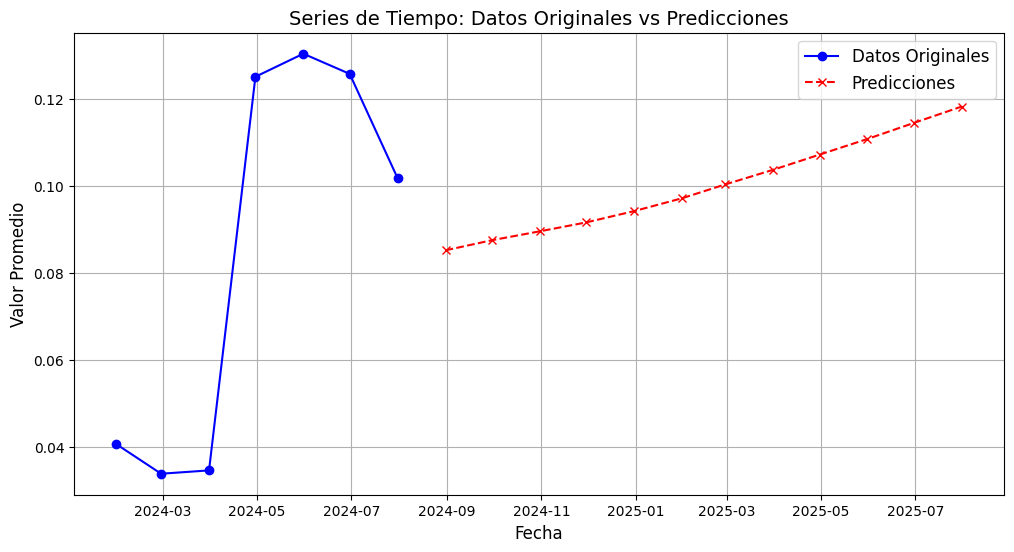

In [ ]:
start_date = "2024-01-01"
# Datos originales (primeras 7 observaciones del track)
original_dates = pd.date_range(start=start_date, periods=7, freq="M")
original_values = [np.mean(track[i, ::, ::, 0]) for i in range(7)]  # Usando el promedio

# Datos predichos (ya calculados en pred_series)
pred_values = [np.mean(mapa) for mapa in pred_series["Mapa"]]

# Combinar datos originales y predicciones
combined_data = pd.DataFrame({
    "Fecha": list(original_dates) + list(pred_series["Fecha"]),
    "Valor": original_values + pred_values,
    "Tipo": ["Original"] * len(original_values) + ["Predicción"] * len(pred_values)
})

# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar datos originales
plt.plot(
    combined_data[combined_data["Tipo"] == "Original"]["Fecha"],
    combined_data[combined_data["Tipo"] == "Original"]["Valor"],
    label="Datos Originales",
    marker="o",
    color="blue"
)

# Graficar predicciones
plt.plot(
    combined_data[combined_data["Tipo"] == "Predicción"]["Fecha"],
    combined_data[combined_data["Tipo"] == "Predicción"]["Valor"],
    label="Predicciones",
    marker="x",
    color="red",
    linestyle="--"
)

# Configurar etiquetas y título
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Valor Promedio", fontsize=12)
plt.title("Series de Tiempo: Datos Originales vs Predicciones", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.savefig(f'{ruta_salida}batch_size_{batch_size}_epochs_{epochs}_validation_split_{validation_split}_prediccion_num_capas_{num_capas}.png')
# Mostrar la gráfica
plt.show()

In [ ]:
start_date

# Desnormalizar predicciones antes de grafica

Para graficar las series de tiempo con las predicciones, y asegurarte primero de eliminar la normalización (es decir, desnormalizar los datos predichos para que estén en la misma escala que los datos raster originales), aquí tienes el procedimiento paso a paso con el código completo.

Voy a asumir lo siguiente:

Tus datos raster de entrada fueron normalizados con una fórmula típica como:

$ normalizado = \dfrac{𝑥 − min}{max − min} $

Entonces, para desnormalizar:

$𝑥 = normalizado × (max−min) + min $

Como utilizamos la siguiente normalización:

$sequences = sequences / sequences.max()$

lo que implica que la desnormalización simplemente consiste en multiplicar por ese mismo valor máximo.

In [ ]:
max_val = sequences.max()  # Guarda este valor antes de normalizar
max_val = track.max()  # Asume que track ya está normalizado
# Desnormaliza las predicciones
pred_series["Mapa_desnormalizado"] = pred_series["Mapa"].apply(lambda x: x * max_val)
pred_series["Valor_promedio"] = pred_series["Mapa_desnormalizado"].apply(np.mean)


In [ ]:


plt.figure(figsize=(12, 6))

plt.plot(
    pred_series["Fecha"],
    pred_series["Valor_promedio"],
    label="Predicción Desnormalizada",
    marker="o",
    linestyle="--",
    color="green"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Valor Promedio del Mapa", fontsize=12)
plt.title("Serie de Tiempo de las Predicciones (Desnormalizadas)", fontsize=14)

plt.savefig(f'{ruta_salida}batch_size_{batch_size}_epochs_{epochs}_validation_split_{validation_split}_prediccion_Desnormalizadas_num_capas_{num_capas}.png')
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# Datos reales y predicción

In [ ]:

# Fecha inicial
start_date = "2024-08-01"

# Fechas
dates_originals = pd.date_range(start=start_date, periods=7, freq="M")
dates_predictions = pd.date_range(start=dates_originals[-1] + pd.DateOffset(months=1), periods=12, freq="M")

# Desnormalización
max_val = track.max()

# Datos originales (primeros 7 mapas)
original_maps = [track[i, :, :, 0] * max_val for i in range(7)]
original_means = [np.mean(mapa) for mapa in original_maps]

# Predicciones (siguientes 12 mapas)
predicted_maps = [track[i + 7, :, :, 0] * max_val for i in range(12)]
predicted_means = [np.mean(mapa) for mapa in predicted_maps]

# Crear DataFrame unificado
df = pd.DataFrame({
    "Fecha": list(dates_originals) + list(dates_predictions),
    "Valor_promedio": original_means + predicted_means,
    "Tipo": ["Original"] * 7 + ["Predicción"] * 12
})

# Gráfica de series de tiempo
plt.figure(figsize=(12, 6))

plt.plot(
    df[df["Tipo"] == "Original"]["Fecha"],
    df[df["Tipo"] == "Original"]["Valor_promedio"],
    label="Datos Originales",
    marker="o",
    color="blue"
)

plt.plot(
    df[df["Tipo"] == "Predicción"]["Fecha"],
    df[df["Tipo"] == "Predicción"]["Valor_promedio"],
    label="Predicciones",
    marker="x",
    linestyle="--",
    color="red"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Valor Promedio del Mapa", fontsize=12)
plt.title("Comparación de Datos Originales y Predicciones", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()



# <font color="#0FFF">📎Entrenamiento y Evaluación del modelo</font>

Indicadores para la evaluación HitRa y HitRn del artículo https://ieeexplore.ieee.org/document/9211482.

*La tasa o índice de aciertos* ($HitR_n$) es uno de los índices utilizados para evaluar la precisión de la predicción de delitos. Esta tasa incluye principalmente la <font color="#0FFF">tasa de acierto de la cuadrícula</font> y la <font color="#FF7">tasa de acierto de casos</font>.

<font color="#0FFF">La tasa de acierto de la cuadrícula</font>

$$HitR_a = \dfrac{a*}{A}$$

donde $A$ es el número total de cuadrículas de puntos calientes reales; y $a*$ es el número total de cuadrículas de puntos calientes predichas correctamente.


<font color="#FF7">La tasa de acierto de casos</font> es

$$HitR_n = \dfrac{n}{N}$$

donde $n$ es el número total de casos en el área de estudio durante este periodo y $N$ es el número real de casos en las cuadrículas calientes pronosticadas. Cuanto mayor sea el valor de $HitR_n$, mayor será el número de casos incluidos en las cuadrículas de pronóstico y mayor la precisión de la predicción.


--------------------------------------------------------------------------
El índice de precisión de predicción ($HitE_n$) también permite evaluar el efecto de predicción del modelo. En un período determinado, al aumentar el número de cuadrículas de predicción, se pueden cubrir más. Cuando el número de cuadrículas de predicción es igual al número total, el valor de HitRn es 1. En este caso, el valor de HitRn es alto, pero el efecto de predicción es bajo. Por lo tanto, se necesita HitEn para medir el efecto del modelo de predicción. Cuanto mayor sea el valor de HitEn, más casos se cubren con menos cuadrículas de predicción y mayor será la eficiencia de acierto

$$ HitE_n= \dfrac{HitR_n}{a*/A} $$

where a refers to the number of predicted hotspot grids and A refers to the actual number of hotspots.

In [ ]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math '''

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# === 1. Normalización global de datos ===

scaler = MinMaxScaler()
# Aplanar todos los datos (entrada y etiquetas)
all_data = np.concatenate([noisy_movies.reshape(-1, 1),
                           shifted_movies.reshape(-1, 1)])
scaler.fit(all_data)

# Aplicar transformación
X = scaler.transform(noisy_movies.reshape(-1,1)).reshape(noisy_movies.shape)
Y = scaler.transform(shifted_movies.reshape(-1,1)).reshape(shifted_movies.shape)

# ====== 2. Construcción del modelo ======
seq = Sequential()

num_capas = 4

for _ in range(num_capas):
    seq.add(ConvLSTM2D(
        filters=36,
        kernel_size=(3, 3),
        input_shape=(None, X.shape[2], X.shape[3], 1),
        padding='same',
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=l2(1e-4),
        recurrent_regularizer=l2(1e-4)
    ))
    #seq.add(BatchNormalization())

# Capa final sin sigmoid, para permitir valores fuera de (0,1)
seq.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='linear', padding='same'))

seq.compile(loss='mean_absolute_error', optimizer='adadelta')

# === 3. Entrenamiento del modelo ===
batch_size = 11; #El tamaño del lote que se usa para actualizar los pesos del modelo después de cada pasada. Es decir, cuántas muestras se procesan antes de realizar un ajuste a los pesos del modelo.
epochs = 50; # El número de veces que el modelo verá todo el conjunto de entrenamiento. Una época implica que el modelo ha pasado por todas las muestras de entrenamiento una vez.
validation_split = 0.1;   # Es el porcentaje de los datos de entrenamiento que se usará como datos de validación para evaluar el rendimiento del modelo durante el entrenamiento.

history = seq.fit(
    X, Y,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    verbose=2,
    shuffle=True
)

# Gráfico de evolución de pérdida por época
#plt.figure(figsize=(8,4))
#plt.plot(history.history['loss'], label='Entrenamiento')
#plt.plot(history.history['val_loss'], label='Validación')
#plt.xlabel('Época')
#plt.ylabel('Pérdida (MSE)')
#plt.title('Evolución de la pérdida por época')
#plt.legend()
#plt.grid(True)
#plt.tight_layout()
#plt.show()

# === 4. Predicción sobre test / validación ===

# Suponiendo que separamos un set test aparte
X_test = X[52:]
Y_test = Y[52:]
Y_pred = seq.predict(X_test)

# Desnormalizar resultados para interpretación adecuada
Y_test_dn = scaler.inverse_transform(Y_test.reshape(-1,1)).reshape(Y_test.shape)
Y_pred_dn = scaler.inverse_transform(Y_pred.reshape(-1,1)).reshape(Y_pred.shape)

# Métricas globales
y_true_flat = Y_test_dn.flatten()
y_pred_flat = Y_pred_dn.flatten()
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = math.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}")

# === 5. Métricas espaciales tipo hotspot adaptadas ===

def hit_metrics(y_true, y_pred, top_percent=10):
    flat_true = y_true.flatten()
    flat_pred = y_pred.flatten()

    th_true = np.percentile(flat_true, 100 - top_percent)
    th_pred = np.percentile(flat_pred, 100 - top_percent)

    mask_true = flat_true >= th_true
    mask_pred = flat_pred >= th_pred

    A = np.sum(mask_true)
    a_pred = np.sum(mask_pred)
    a_corr = np.sum(mask_true & mask_pred)

    N = np.sum(flat_true[mask_true & mask_pred])
    n = np.sum(flat_true)

    HitRa = a_corr / A
    HitRn = N / n
    HitEn = HitRn * (A / a_pred)

    return HitRa, HitRn, HitEn

HitRa, HitRn, HitEn = hit_metrics(Y_test_dn.reshape(-1,90, 124,1),
                                  Y_pred_dn.reshape(-1,90, 124,1),
                                  top_percent=10)
print(f"HitRa: {HitRa:.3f}, HitRn: {HitRn:.3f}, HitEn: {HitEn:.3f}")

print(f"  MAE={mae:.3f}, RMSE={rmse:.3f}")

# === 6. Comparación antes/después de covariables ===

# Imagina que agregaste POI y entrenaste otro modelo seq_cov
# Repite pasos 2–4 para obtener mae_cov, rmse_cov, HitEn_cov
# Luego imprime:

#print("=== Sin covariables ===")
#print(f"  MAE={mae:.3f}, RMSE={rmse:.3f}, HitEn={HitEn:.3f}")
# print("=== Con covariables ===")
# print(f"  MAE={mae_cov:.3f}, RMSE={rmse_cov:.3f}, HitEn={HitEn_cov:.3f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: You must call `compile()` before using the model.

# Mejoras al modelo


 - barrido de los hiper parámetros para que disminuya el error
 - en principio hay que comenzar por dejar más épocas,
 - aumentar el tamaño de batch,
 - más neuronas en las capas ocultas,

en ese orden e implemnetando un cambio a la vez

In [ ]:
    batch_size=11,
    epochs=50,
    validation_split=0.1,
    num_capas = 4

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# === 1. Normalización global de datos ===

scaler = MinMaxScaler()
# Aplanar todos los datos (entrada y etiquetas)
all_data = np.concatenate([noisy_movies.reshape(-1, 1),
                           shifted_movies.reshape(-1, 1)])
scaler.fit(all_data)

# Aplicar transformación
X = scaler.transform(noisy_movies.reshape(-1,1)).reshape(noisy_movies.shape)
Y = scaler.transform(shifted_movies.reshape(-1,1)).reshape(shifted_movies.shape)

# Reconstruye tu modelo añadiendo dropout y regularización L2
seq = Sequential()
for _ in range(4):
    seq.add(ConvLSTM2D(filters=36, kernel_size=(3,3),
                       padding='same', return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.2,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))
    #seq.add(BatchNormalization())

seq.add(Conv3D(filters=1, kernel_size=(3,3,3),
               activation='sigmoid', padding='same',
               kernel_regularizer=l2(1e-4)))

seq.compile(loss='mean_absolute_error', optimizer='adadelta')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = seq.fit(
    X, Y,
    batch_size=11,
    epochs=50,
    validation_split=0.1,
    shuffle=True,
    callbacks=callbacks,
    verbose=2
)
seq.summary()

Epoch 1/50
5/5 - 82s - 16s/step - loss: 0.4766 - val_loss: 0.4340 - learning_rate: 1.0000e-03
Epoch 2/50
5/5 - 10s - 2s/step - loss: 0.4766 - val_loss: 0.4340 - learning_rate: 1.0000e-03
Epoch 3/50
5/5 - 10s - 2s/step - loss: 0.4766 - val_loss: 0.4340 - learning_rate: 1.0000e-03
Epoch 4/50
5/5 - 10s - 2s/step - loss: 0.4766 - val_loss: 0.4340 - learning_rate: 1.0000e-03
Epoch 5/50
5/5 - 10s - 2s/step - loss: 0.4766 - val_loss: 0.4340 - learning_rate: 5.0000e-04
Epoch 6/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4340 - learning_rate: 5.0000e-04
Epoch 7/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4340 - learning_rate: 5.0000e-04
Epoch 8/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4340 - learning_rate: 2.5000e-04
Epoch 9/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4339 - learning_rate: 2.5000e-04
Epoch 10/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4339 - learning_rate: 2.5000e-04
Epoch 11/50
5/5 - 10s - 2s/step - loss: 0.4765 - val_loss: 0.4339 - 

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_16 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        48,096 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_17 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_18 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_19 (ConvLSTM2D)     │ (None, 12, 90, 124,    │        93,456 │
│                                 │ 36)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 12, 90, 124, 1) │           973 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,313 (3.77 MB)

 Trainable params: 329,437 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 658,876 (2.51 MB)

In [ ]:
which = 26
track = noisy_movies[which][:7, ::, ::, ::]
noisy_movies[which].shape #la secuencia 33 tiene los 12 meses
track.shape, track[np.newaxis, ::, ::, ::, ::].shape  #alimenta a seq para predecir

for j in range(12): #16 meses predichos
   # seq Guarda la red entrenada
    new_pos = seq.predict(track[np.newaxis, ::, ::, ::, ::]) # (1, 7, 80, 80, 1)
    new = new_pos[::, -1, ::, ::, ::] # (1, 80, 80, 1)
    #en track se guardan las prediccioenes
    track = np.concatenate((track, new), axis=0) # adds +1 to the first dimension in each loop cycle
    #contiene una pelicula

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


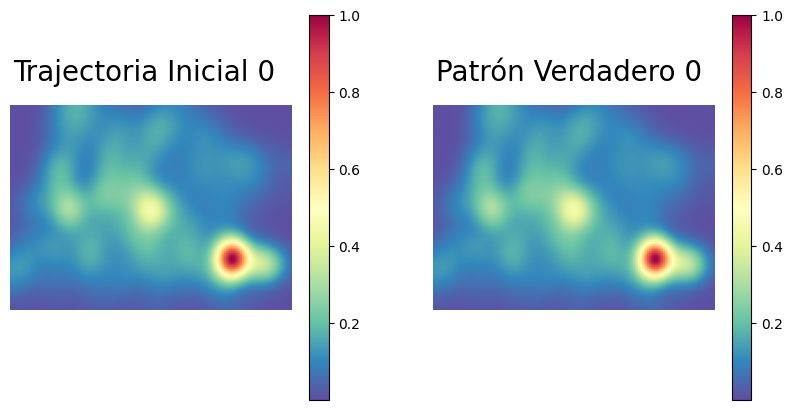

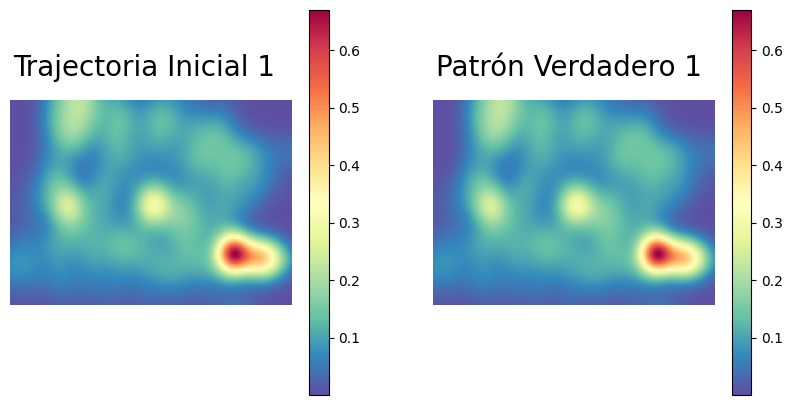

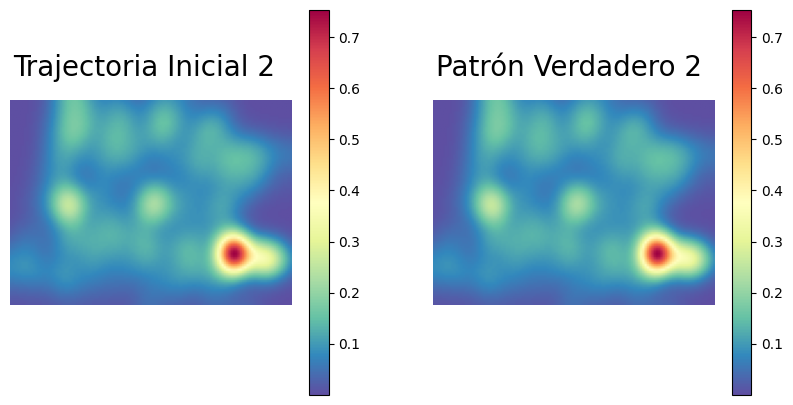

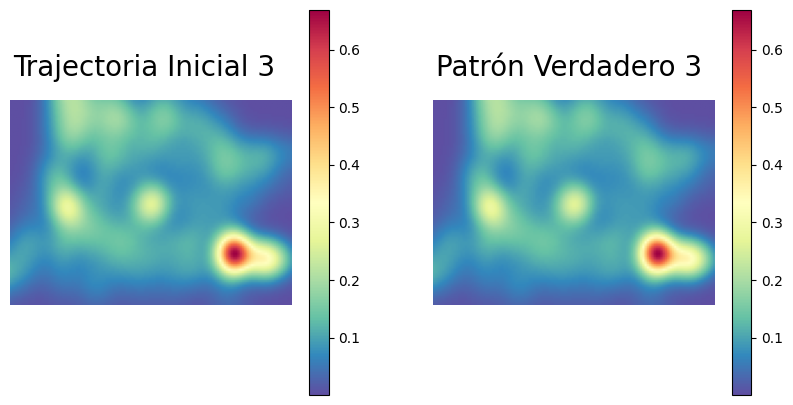

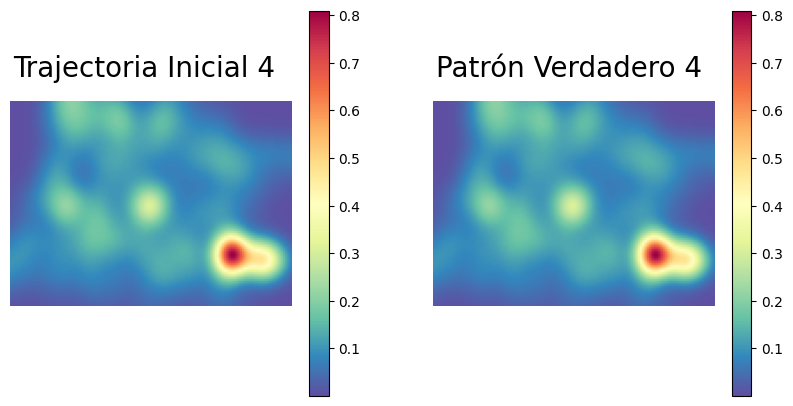

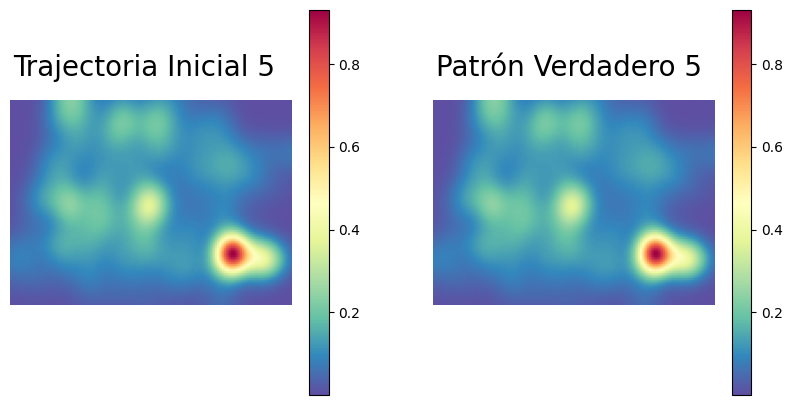

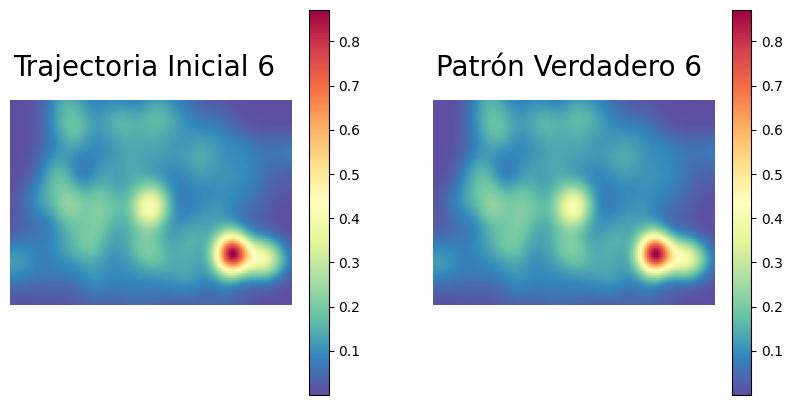

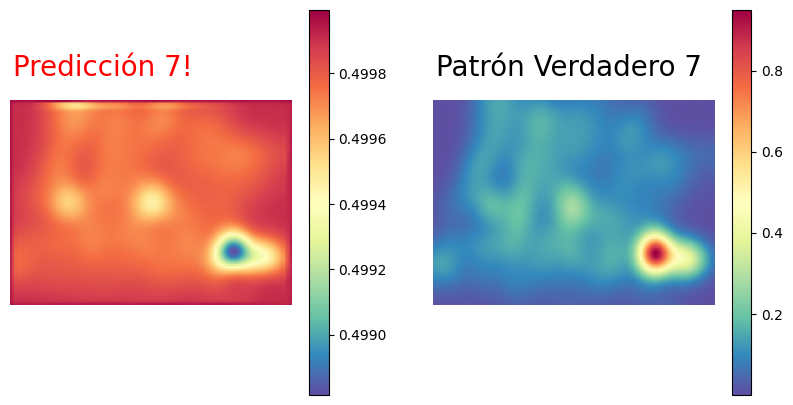

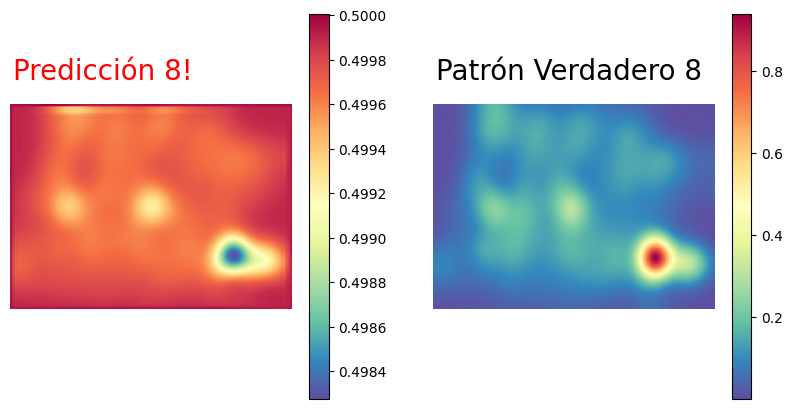

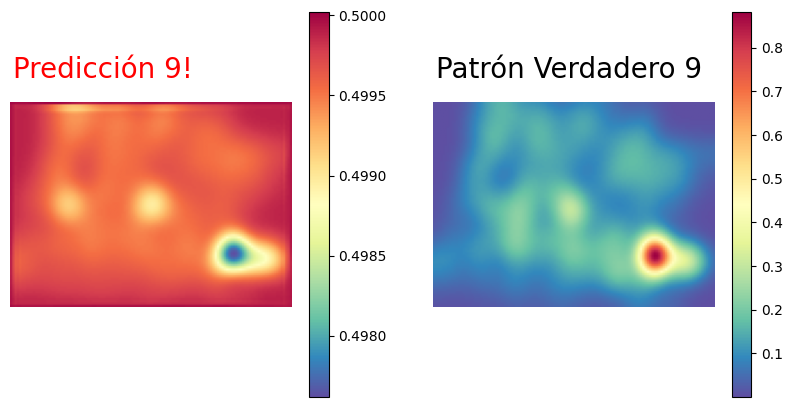

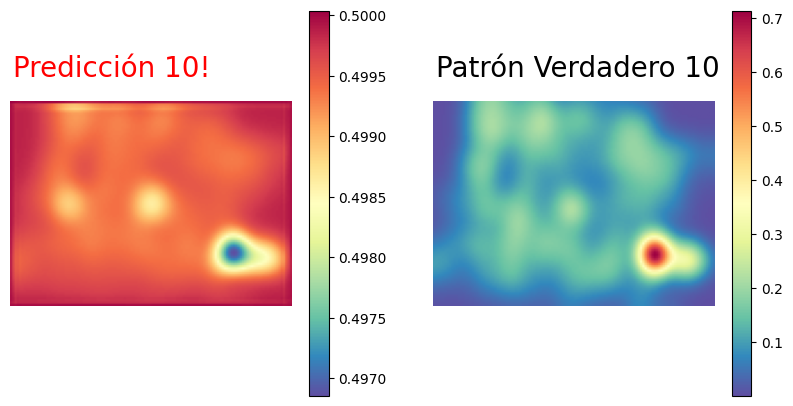

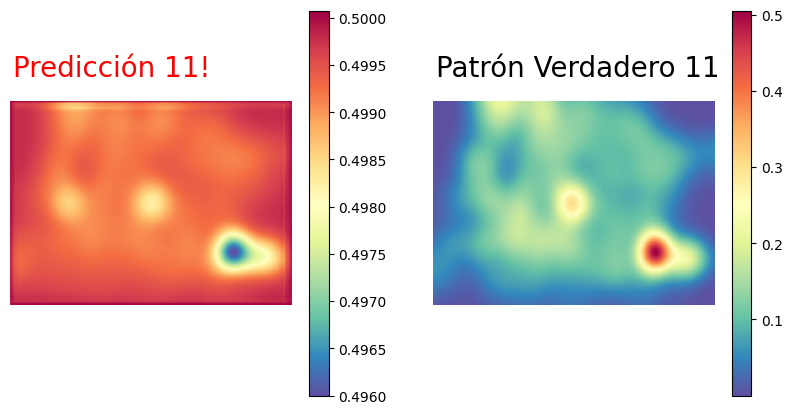

In [ ]:
#range debe ser menor a sample
for i in range(12): #range debe ser menor a sample
    fig = plt.figure(figsize=(10, 5))

    ax = fig.add_subplot(121)

    if i >= 7:
        ax.text(1, 3, f'Predicción {i}!\n', fontsize=20, color='r')
    else:
        ax.text(1, 3, f'Trajectoria Inicial {i}\n', fontsize=20)
    #Datos Predichos
    toplot = track[i, ::, ::, 0]
    #plt.imshow(toplot, cmap = 'Spectral_r')
    plt.imshow(toplot, cmap='Spectral_r', vmin=np.min(toplot), vmax=np.max(toplot))
    plt.colorbar()
    plt.axis('off')
    ax = fig.add_subplot(122)
    plt.text(1, 3, f'Patrón Verdadero {i}\n', fontsize=20)

    #Datos Reales
    toplot = track[i, ::, ::, 0]
    if i >= 2:
        toplot = shifted_movies[which][i - 1, ::, ::, 0]

    plt.imshow(toplot, cmap='Spectral_r')
    plt.colorbar()
    plt.axis('off')

    plt.savefig(f'{ruta_salida}_predicciones_batch_size_{batch_size}_epochs_{epochs}_validation_split_{validation_split}_%i_animate_num_capas_{num_capas}_sin_normalizar.png' % (i + 1))


In [ ]:

# === 3. Predicción sobre test / validación ===

# Suponiendo que separamos un set test aparte
X_test = X[52:]
Y_test = Y[52:]
Y_pred = seq.predict(X_test)

# Desnormalizar resultados para interpretación adecuada
Y_test_dn = scaler.inverse_transform(Y_test.reshape(-1,1)).reshape(Y_test.shape)
Y_pred_dn = scaler.inverse_transform(Y_pred.reshape(-1,1)).reshape(Y_pred.shape)

# Métricas globales
y_true_flat = Y_test_dn.flatten()
y_pred_flat = Y_pred_dn.flatten()
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = math.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}")

# === 4. Métricas espaciales tipo hotspot adaptadas ===

def hit_metrics(y_true, y_pred, top_percent=10):
  #El método numpy.ndarray.flatten devuelve una copia del array colapsado a una única dimensión.
    flat_true = y_true.flatten()
    flat_pred = y_pred.flatten()
 #indica el porcentaje de datos que son iguales o inferiores al percentil 90
    th_true = np.percentile(flat_true, 100 - top_percent)
    th_pred = np.percentile(flat_pred, 100 - top_percent)

    mask_true = flat_true >= th_true
    mask_pred = flat_pred >= th_pred

    A = np.sum(mask_true)
    a_pred = np.sum(mask_pred)
    a_corr = np.sum(mask_true & mask_pred)

    N = np.sum(flat_true[mask_true & mask_pred])
    n = np.sum(flat_true)

    HitRa = a_corr / A
    HitRn = N / n
    HitEn = HitRn * (A / a_pred)

    return HitRa, HitRn, HitEn

HitRa, HitRn, HitEn = hit_metrics(Y_test_dn.reshape(-1,90, 124,1),
                                  Y_pred_dn.reshape(-1,90, 124,1),
                                  top_percent=10)
print(f"HitRa: {HitRa:.3f}, HitRn: {HitRn:.3f}, HitEn: {HitEn:.3f}")


# === 5. Comparación antes/después de covariables ===

# Imagina que agregaste POI y entrenaste otro modelo seq_cov
# Repite pasos 2–4 para obtener mae_cov, rmse_cov, HitEn_cov
# Luego imprime:

#print("=== Sin covariables ===")
#print(f"  MAE={mae:.3f}, RMSE={rmse:.3f}, HitEn={HitEn:.3f}")
# print("=== Con covariables ===")
# print(f"  MAE={mae_cov:.3f}, RMSE={rmse_cov:.3f}, HitEn={HitEn_cov:.3f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
MAE: 0.357, RMSE: 0.368
HitRa: 0.208, HitRn: 0.042, HitEn: 0.042


# <font color="#0FFF"> Modificaciones para la segunda Ronda de Revisión </font>


El siguiente código está diseñado para medir Métricas Espaciales. Solo necesitas pasarle tus mapas de calor predichos y reales (como arrays de NumPy) y los datos de los crímenes reales.




In [ ]:
import numpy as np

def discretize_heatmap(heatmap, threshold_percentage):
    """
    Convierte un mapa de calor continuo en un mapa de hotspots binario.

    Define como hotspot (valor 1) a las celdas que están por encima de un
    cierto percentil de densidad.

    Args:
        heatmap (np.array): Array 2D de NumPy con los valores de densidad.
        threshold_percentage (float): El porcentaje del área a ser considerado
                                      como hotspot (ej. 10.0 para el 10% superior).

    Returns:
        np.array: Un array 2D binario (0s y 1s) del mismo tamaño que el heatmap.
    """
    if not (0 < threshold_percentage <= 100):
        raise ValueError("El porcentaje del umbral debe estar entre 0 y 100.")

    # Se calcula el valor de densidad en el percentil deseado.
    # Si queremos el 10% superior, necesitamos el valor en el percentil 90.
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)

    # Se genera el mapa binario: 1 si el valor de la celda es >= al umbral, 0 en caso contrario.
    hotspot_map = (heatmap >= threshold_value).astype(int)

    return hotspot_map

def calculate_iou(predicted_hotspots, true_hotspots):
    """
    Calcula la métrica Intersection over Union (IoU) entre dos mapas de hotspots binarios.

    Args:
        predicted_hotspots (np.array): Mapa binario de los hotspots predichos.
        true_hotspots (np.array): Mapa binario de los hotspots reales.

    Returns:
        float: El valor de IoU (entre 0.0 y 1.0).
    """
    # La intersección son las celdas donde ambos mapas tienen un 1.
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))

    # La unión son las celdas donde al menos un mapa tiene un 1.
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))

    # Manejo de división por cero si no hay hotspots en ningún mapa.
    if union == 0:
        return 1.0 # Si ambos son vacíos, la predicción es perfecta.

    return intersection / union

def calculate_pai(predicted_hotspots, true_crime_locations):
    """
    Calcula el Índice de Precisión Predictiva (PAI).

    PAI = (% de crímenes en hotspots predichos) / (% de área cubierta por hotspots predichos)

    Args:
        predicted_hotspots (np.array): Mapa binario de los hotspots predichos.
        true_crime_locations (list of tuples): Una lista de coordenadas (fila, col)
                                               de donde ocurrieron los crímenes reales.

    Returns:
        float: El valor de PAI. Un valor > 1.0 indica que el modelo es mejor que el azar.
    """
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)

    # Manejo de caso donde no se predice ningún hotspot.
    if hotspot_area == 0:
        return 0.0

    percentage_area = hotspot_area / total_area

    total_crimes = len(true_crime_locations)

    # Manejo de caso donde no hay crímenes para evaluar.
    if total_crimes == 0:
        return 0.0 # O podría ser indefinido, dependiendo del contexto.

    # Contar cuántos crímenes cayeron dentro de los hotspots predichos.
    crimes_in_hotspots = 0
    for r, c in true_crime_locations:
        # Asegurarse de que las coordenadas están dentro de los límites del mapa.
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]:
            if predicted_hotspots[r, c] == 1:
                crimes_in_hotspots += 1

    percentage_crimes = crimes_in_hotspots / total_crimes

    return percentage_crimes / percentage_area


In [ ]:
# --- EJEMPLO DE USO ---
if __name__ == '__main__':
    # 1. Definir parámetros
    GRID_HEIGHT, GRID_WIDTH = 90, 120
    HOTSPOT_THRESHOLD_PERCENTAGE = 10.0 # Definimos hotspots como el 10% del área con más crimen.

    # 2. Simular datos de entrada (reemplazar con tus datos reales)

    # Mapa de calor REAL (ground truth): Simula un gran hotspot en el centro.
    true_heatmap = np.zeros((GRID_HEIGHT, GRID_WIDTH))
    true_heatmap[30:60, 45:75] = np.random.uniform(0.5, 1.0, size=(30, 30))

    # Mapa de calor PREDICHO: Simula un hotspot que se superpone parcialmente con el real.
    predicted_heatmap = np.zeros((GRID_HEIGHT, GRID_WIDTH))
    predicted_heatmap[40:70, 55:85] = np.random.uniform(0.4, 0.9, size=(30, 30))
    predicted_heatmap += np.random.rand(GRID_HEIGHT, GRID_WIDTH) * 0.1 # Añadir algo de ruido

    # Coordenadas de crímenes REALES:
    # 150 crímenes dentro del hotspot real, 50 fuera.
    true_crime_locations = []
    # Crímenes dentro del hotspot
    for _ in range(150):
        r = np.random.randint(30, 60)
        c = np.random.randint(45, 75)
        true_crime_locations.append((r, c))
    # Crímenes fuera del hotspot
    for _ in range(50):
        r = np.random.randint(0, GRID_HEIGHT)
        c = np.random.randint(0, GRID_WIDTH)
        true_crime_locations.append((r, c))

    # 3. Proceso de Evaluación

    # Paso 1: Discretizar ambos mapas de calor para obtener áreas de hotspots.
    true_hotspots_map = discretize_heatmap(true_heatmap, HOTSPOT_THRESHOLD_PERCENTAGE)
    predicted_hotspots_map = discretize_heatmap(predicted_heatmap, HOTSPOT_THRESHOLD_PERCENTAGE)

    # Paso 2: Calcular las métricas.
    iou_score = calculate_iou(predicted_hotspots_map, true_hotspots_map)
    pai_score = calculate_pai(predicted_hotspots_map, true_crime_locations)

    # 4. Imprimir resultados
    print(f"--- Evaluación del Modelo Predictivo de Hotspots ---")
    print(f"Umbral de Hotspot: {HOTSPOT_THRESHOLD_PERCENTAGE}% del área más densa.\n")

    print(f"Intersection over Union (IoU): {iou_score:.4f}")
    print("Interpretación de IoU: Mide la precisión espacial de los hotspots.")
    print("Un valor cercano a 1.0 es ideal (perfecta superposición). Un valor > 0.5 suele considerarse bueno.\n")

    print(f"Predictive Accuracy Index (PAI): {pai_score:.4f}")
    print("Interpretación de PAI: Mide la eficiencia del modelo.")
    print(f"Un valor de {pai_score:.2f} significa que el modelo es {pai_score:.2f} veces mejor que predecir al azar.")
    print("Un PAI > 1.0 es el requisito mínimo para que el modelo sea útil.\n")


--- Evaluación del Modelo Predictivo de Hotspots ---
Umbral de Hotspot: 10.0% del área más densa.

Intersection over Union (IoU): 0.1000
Interpretación de IoU: Mide la precisión espacial de los hotspots.
Un valor cercano a 1.0 es ideal (perfecta superposición). Un valor > 0.5 suele considerarse bueno.

Predictive Accuracy Index (PAI): 3.2500
Interpretación de PAI: Mide la eficiencia del modelo.
Un valor de 3.25 significa que el modelo es 3.25 veces mejor que predecir al azar.
Un PAI > 1.0 es el requisito mínimo para que el modelo sea útil.

